# E-Commerce Customer Churn Prediction

**Objective:** Predict whether a customer will churn using behavioral and transactional data.

**Dataset:** `ecommerce_customer_churn_dataset.csv`

**Problem Statement:**  
Churn is costly for e-commerce businesses. This project explores customer churn patterns and builds predictive models to identify customers at high risk of leaving.

In [119]:
import pandas as pd

df = pd.read_csv("ecommerce_customer_churn_dataset.csv")
df.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,...,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,...,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,...,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,...,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,...,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,...,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


## 1. Data Exploration

In [120]:
df.columns

Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')

In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

In [122]:
df['Churned'].value_counts()

,count
Churned,
0,35550
1,14450


In [123]:
df.isna().sum()

,0
Age,2495
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,3399
Pages_Per_Session,3000
Cart_Abandonment_Rate,0
Wishlist_Items,4000



## 2. Data Preprocessing

In [124]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)

Numerical: ['Age', 'Membership_Years', 'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session', 'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases', 'Average_Order_Value', 'Days_Since_Last_Purchase', 'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate', 'Customer_Service_Calls', 'Product_Reviews_Written', 'Social_Media_Engagement_Score', 'Mobile_App_Usage', 'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance', 'Churned']
Categorical: ['Gender', 'Country', 'City', 'Signup_Quarter']


In [125]:
# =========================================
# Handle Missing Values
# =========================================

# Numerical → fill with median
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical → fill with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [126]:
df.isna().sum()

,0
Age,0
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,0
Pages_Per_Session,0
Cart_Abandonment_Rate,0
Wishlist_Items,0


In [127]:
df.duplicated().sum()

np.int64(0)

In [128]:
df = df.drop(columns=['City'])

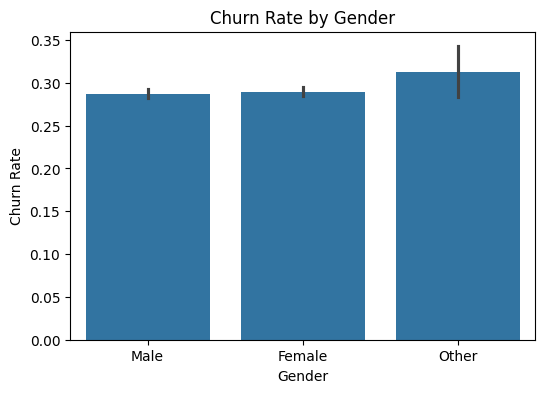

In [129]:
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.barplot(x='Gender', y='Churned', data=df)
plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate")
plt.show()

### Interpretation: Churn Rate by Gender

- **Male and Female customers show nearly identical churn rates** (around 29%).
- **'Other' gender category** shows a slightly higher churn rate (~32%) but has a wider confidence interval—suggesting less data for this group, so that rate may be less reliable.
- **Business takeaway:**  
  No major gender-based churn differences detected. Retention efforts should focus on behavior/engagement segments rather than gender. However, it's important to monitor ‘Other’ category churn if the sample size grows.

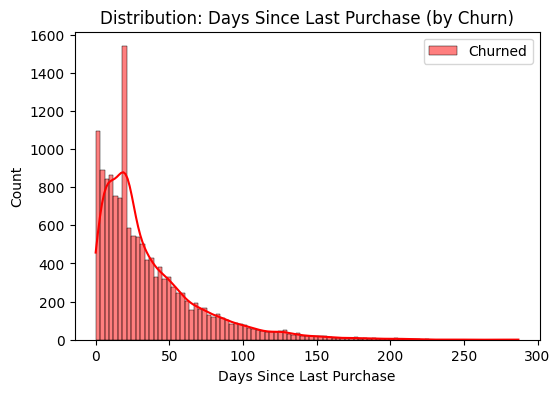

In [130]:
plt.figure(figsize=(6, 4))
sns.histplot(df[df['Churned']==1]['Days_Since_Last_Purchase'], kde=True, label='Churned', color='red')
plt.title("Distribution: Days Since Last Purchase (by Churn)")
plt.xlabel("Days Since Last Purchase")
plt.legend()
plt.show()

### Interpretation: Distribution of Days Since Last Purchase (Churned Customers)

- Most churned customers have not made a purchase in a long time. The distribution is right-skewed, with churned users concentrated at higher values for "Days Since Last Purchase."
- Very few churned customers made recent purchases (within the last 10 days).
- **Takeaway:** "Days Since Last Purchase" is a strong indicator of churn risk. We should focus retention and re-engagement efforts on users with long inactivity periods, as their likelihood to churn is much higher.


## 3. Modeling & Evaluation

In [131]:
df = pd.get_dummies(df, drop_first=True)

In [132]:
X = df.drop('Churned', axis=1)
y = df['Churned']

In [133]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [135]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [136]:
y_pred = model.predict(X_test)

In [137]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86      7130
           1       0.69      0.42      0.52      2870

    accuracy                           0.78     10000
   macro avg       0.74      0.67      0.69     10000
weighted avg       0.77      0.78      0.76     10000



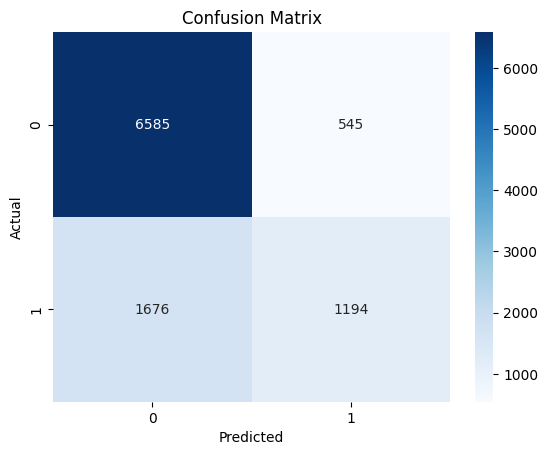

In [138]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [139]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [140]:
y_pred_rf = rf_model.predict(X_test)

In [141]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7130
           1       0.92      0.77      0.84      2870

    accuracy                           0.92     10000
   macro avg       0.92      0.87      0.89     10000
weighted avg       0.92      0.92      0.91     10000



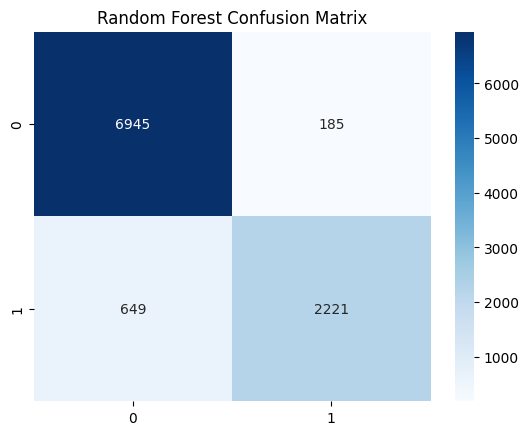

In [142]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.show()

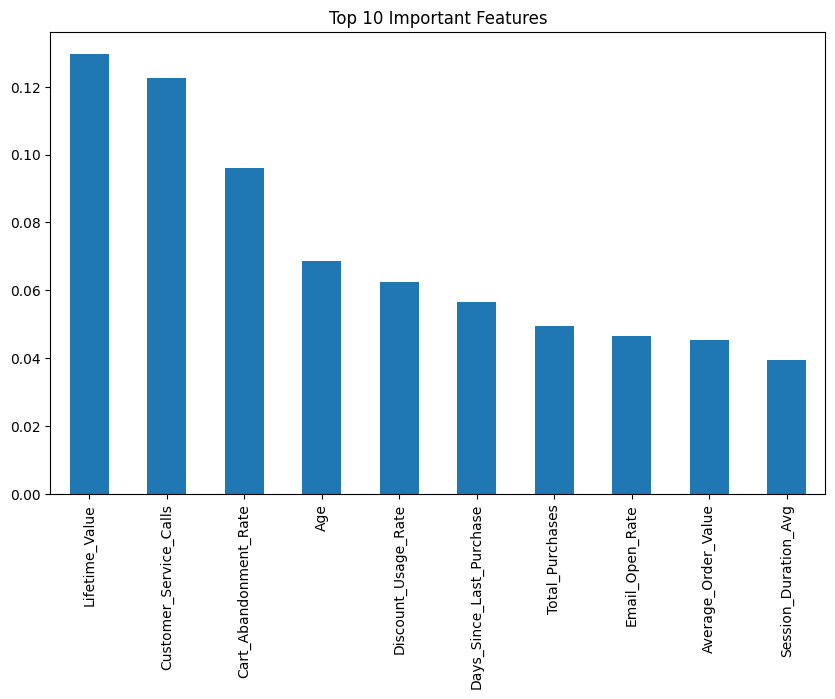

In [143]:
feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

In [145]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
metrics = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
    ],
    "F1-score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
    ],
})

print(metrics)
print(metrics)

                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression    0.7779   0.686601  0.416028  0.518117
1        Random Forest    0.9166   0.923109  0.773868  0.841926
                 Model  Accuracy  Precision    Recall  F1-score
0  Logistic Regression    0.7779   0.686601  0.416028  0.518117
1        Random Forest    0.9166   0.923109  0.773868  0.841926


### Model Comparison: Performance Metrics

| Model                | Accuracy | Precision | Recall | F1-score |
|----------------------|----------|-----------|--------|----------|
| Logistic Regression  | 0.778    | 0.687     | 0.416  | 0.518    |
| Random Forest        | 0.917    | 0.923     | 0.774  | 0.842    |

- **Random Forest significantly outperforms Logistic Regression on all metrics**.
    - **Accuracy:** Random Forest (91.7%) vs Logistic Regression (77.8%)
    - **Recall** (churn detection): Random Forest (77.4%) vs Logistic Regression (41.6%)
    - **F1-score**: Random Forest (0.84 vs 0.52)
- **Interpretation:**  
  Random Forest is much better at identifying churned customers—it catches a higher proportion of actual churners (recall), makes fewer mistakes (precision), and overall provides stronger performance.
- **Recommendation:**  
  For production or business use, Random Forest should be preferred for churn prediction in this dataset.


## 4. Conclusions & Next Steps

In [ ]:
"""
Key Insights from the Model:

1. Days_Since_Last_Purchase is the strongest predictor of churn.
   → Customers who haven’t purchased recently are highly likely to churn.

2. Customer_Service_Calls is highly important.
   → Customers contacting support frequently are more likely to churn (possible dissatisfaction).

3. Returns_Rate and Cart_Abandonment_Rate are strong churn signals.
   → Negative shopping experiences increase churn risk.

4. Engagement metrics like Login_Frequency and Session_Duration also matter.
   → Less engaged users are more likely to churn.

5. Lifetime_Value and Total_Purchases contribute to churn prediction.
   → High-value customers behave differently and require targeted retention strategies.
"""